In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from xgboost import XGBClassifier

from sklearn.metrics import roc_auc_score, precision_recall_curve, confusion_matrix

from sklearn.metrics import confusion_matrix, classification_report

## Data importing & Data Cleaning Preprocessing

In [10]:
Geo = pd.read_csv("Data/Geo_scores.csv")
Geo.head(5)

,id,geo_score
0,26674,4.48
1,204314,4.48
2,176521,5.17
3,48812,-2.41
4,126870,6.55


In [14]:
#Data cleaning
print(Geo.isna().sum())
print(Geo.info())

id               0
geo_score    71543
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   id         1424035 non-null  int64  
 1   geo_score  1352492 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
None


In [15]:
#Fill missing Values
Geo['geo_score'] = pd.to_numeric(Geo['geo_score'], errors='coerce')
Geo['geo_score'] = Geo['geo_score'].fillna(Geo['geo_score'].median())
print(Geo.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   id         1424035 non-null  int64  
 1   geo_score  1424035 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
None


In [17]:
Geo = Geo.groupby('id').mean().reset_index()
Geo.head(5)

,id,geo_score
0,0,-0.620
1,1,1.106
2,2,0.070
3,3,0.180
4,4,0.540


In [19]:
instance = pd.read_csv("Data/instance_scores.csv")
instance.head(10)

,id,instance_scores
0,173444,-0.88
1,259378,1.50
2,161170,0.44
3,191161,0.76
4,34521,-0.84
5,115450,0.64
6,149830,-0.64
7,95302,0.24
8,13778,0.28
9,187014,-0.40


In [21]:
#Data cleaning
print(instance.isna().sum())
print(instance.info())

id                 0
instance_scores    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   id               1424035 non-null  int64  
 1   instance_scores  1424035 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
None


In [22]:
Qset = pd.read_csv("Data/Qset_tats.csv")
Qset.head(10)

,id,qsets_normalized_tat
0,9983,2.41
1,266000,3.10
2,77525,1.03
3,160765,-11.63
4,138220,-4.48
5,53869,5.86
6,145189,-32.97
7,122291,3.79
8,249962,-3.10
9,138625,2.41


In [24]:
#Data cleaning
print(Qset.isna().sum())
print(Qset.info())

id                           0
qsets_normalized_tat    103201
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1424035 non-null  int64  
 1   qsets_normalized_tat  1320834 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
None


In [25]:
#Fill missing Values
Qset['qsets_normalized_tat'] = pd.to_numeric(Qset['qsets_normalized_tat'], errors='coerce')
Qset['qsets_normalized_tat'] = Qset['qsets_normalized_tat'].fillna(Qset['qsets_normalized_tat'].median())
print(Qset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1424035 non-null  int64  
 1   qsets_normalized_tat  1424035 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
None


In [30]:
Qset = Qset.groupby('id').mean().reset_index()
Qset.head()

,id,qsets_normalized_tat
0,0,0.214
1,1,-0.110
2,2,1.110
3,3,-0.676
4,4,-0.240


In [34]:
lambda_wts  = pd.read_csv("Data/Lambda_wts.csv")
lambda_wts.head(5)

,Group,lambda_wt
0,Grp936,3.41
1,Grp347,-2.88
2,Grp188,0.39
3,Grp1053,-2.75
4,Grp56,-0.83


In [35]:
#Data cleaning
print(lambda_wts.isna().sum())
print(lambda_wts.info())

Group        0
lambda_wt    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Group      1400 non-null   object 
 1   lambda_wt  1400 non-null   float64
dtypes: float64(1), object(1)
memory usage: 22.0+ KB
None


In [45]:
train = pd.read_csv("Data/train.csv") 
test = pd.read_csv("Data/test_share.csv")
train.head(5)
train.columns

Index(['id', 'Group', 'Per1', 'Per2', 'Per3', 'Per4', 'Per5', 'Per6', 'Per7',
       'Per8', 'Per9', 'Dem1', 'Dem2', 'Dem3', 'Dem4', 'Dem5', 'Dem6', 'Dem7',
       'Dem8', 'Dem9', 'Cred1', 'Cred2', 'Cred3', 'Cred4', 'Cred5', 'Cred6',
       'Normalised_FNT', 'Target'],
      dtype='object')

## Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Fraud Vs Transaction')

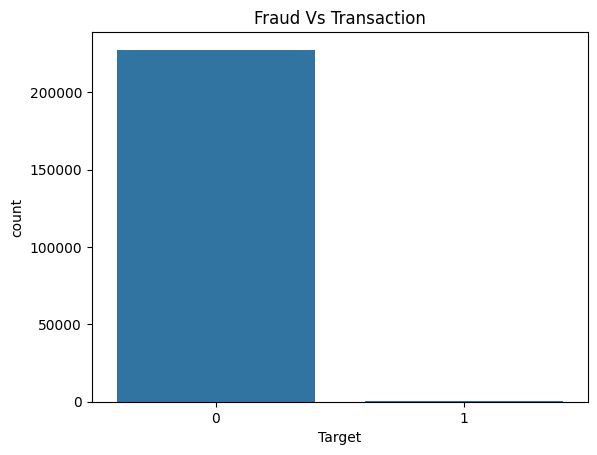

In [41]:
sns.countplot(x='Target', data=train)
plt.title("Fraud Vs Transaction")

Text(0.5, 1.0, 'Distribution of Normalised_FNT')

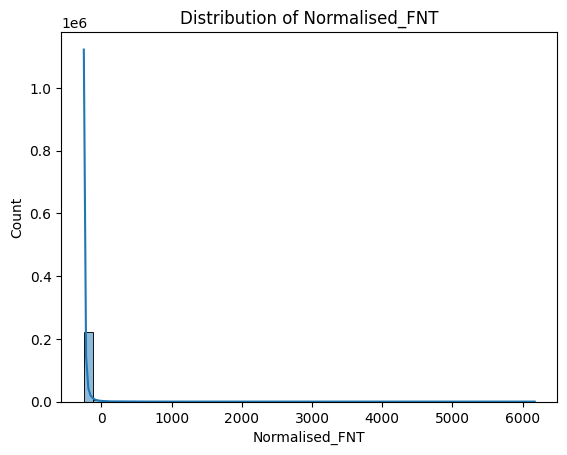

In [46]:
sns.histplot(train['Normalised_FNT'], bins=50, kde=True)
plt.title("Distribution of Normalised_FNT")

<Axes: >

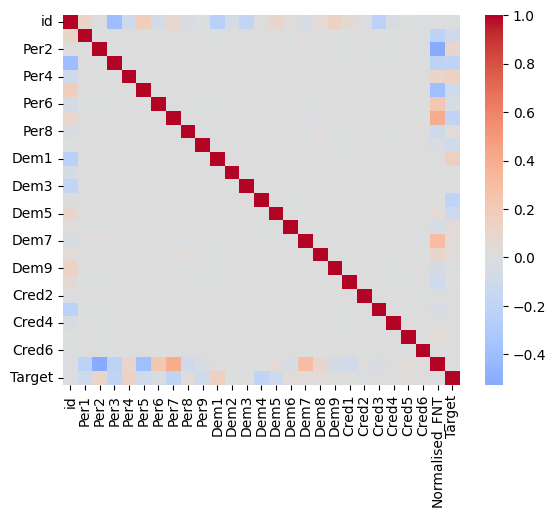

In [49]:
corr = train.select_dtypes(include=['number']).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)

In [50]:
num_cols = train.select_dtypes(include=['number']).columns
cat_cols = train.select_dtypes(exclude=['number']).columns

In [51]:
num_cols

Index(['id', 'Per1', 'Per2', 'Per3', 'Per4', 'Per5', 'Per6', 'Per7', 'Per8',
       'Per9', 'Dem1', 'Dem2', 'Dem3', 'Dem4', 'Dem5', 'Dem6', 'Dem7', 'Dem8',
       'Dem9', 'Cred1', 'Cred2', 'Cred3', 'Cred4', 'Cred5', 'Cred6',
       'Normalised_FNT', 'Target'],
      dtype='object')

In [52]:
cat_cols

Index(['Group'], dtype='object')

## Feature Engineering

In [54]:
train = train.merge(Geo, on="id", how="left")
train = train.merge(Qset, on="id", how="left")
train = train.merge(instance, on="id", how="left")
train = train.merge(lambda_wts, on="Group", how="left")

train['RiskIndex'] = train['geo_score'] + train['instance_scores'] + train['lambda_wt']
train['TatRatio'] = train['qsets_normalized_tat'] / (train['Normalised_FNT'].abs() + 1)

train.head(10)


,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Cred5,Cred6,Normalised_FNT,Target,geo_score,qsets_normalized_tat,instance_scores,lambda_wt,RiskIndex,TatRatio
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.34,1.010000,...,0.686667,0.673333,-245.75,0,0.256,-0.70,-0.36,-0.13,-0.234,-0.002837
1,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.34,1.010000,...,0.686667,0.673333,-245.75,0,0.256,-0.70,-0.24,-0.13,-0.114,-0.002837
2,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.34,1.010000,...,0.686667,0.673333,-245.75,0,0.256,-0.70,0.34,-0.13,0.466,-0.002837
3,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.34,1.010000,...,0.686667,0.673333,-245.75,0,0.256,-0.70,0.68,-0.13,0.806,-0.002837
4,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.34,1.010000,...,0.686667,0.673333,-245.75,0,0.256,-0.70,-0.72,-0.13,-0.594,-0.002837
5,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.81,0.783333,...,0.553333,0.653333,-248.00,0,-0.250,0.14,-0.64,0.66,-0.230,0.000562
6,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.81,0.783333,...,0.553333,0.653333,-248.00,0,-0.250,0.14,4.44,0.66,4.850,0.000562
7,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.81,0.783333,...,0.553333,0.653333,-248.00,0,-0.250,0.14,0.76,0.66,1.170,0.000562
8,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.81,0.783333,...,0.553333,0.653333,-248.00,0,-0.250,0.14,-0.96,0.66,-0.550,0.000562
9,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.81,0.783333,...,0.553333,0.653333,-248.00,0,-0.250,0.14,-1.00,0.66,-0.590,0.000562


## Modeling

In [56]:
x = train.drop(columns=['Target', 'id', 'Group'])
y = train['Target']

X_train, X_val, Y_train, Y_val = train_test_split(x, y, test_size=0.2, stratify=y)

In [78]:
rf = RandomForestClassifier(n_estimators=55, class_weight='balanced', random_state=42)
rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",55
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [79]:
logreg = LogisticRegression(max_iter=55, class_weight='balanced')
logreg.fit(X_train, Y_train)

C:\Users\LENOVO\OneDrive\Desktop\Transaction\om\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 55 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=55).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [80]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05, 
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss" )
xgb.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Evaluation

ROC_AUC of RandomForestClassifier : 1.0
ROC_AUC of LogisticRegression : 0.9899420965260839
ROC_AUC of XGBClassifier : 1.0


Text(0.5, 1.0, 'Precision-Recall Curve of RandomForestClassifier')

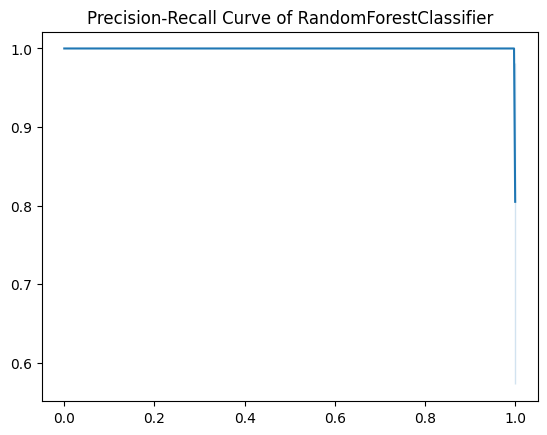

In [81]:
y_pred_proba_rf = rf.predict_proba(X_val)[:,1]
print("ROC_AUC of RandomForestClassifier :", roc_auc_score(Y_val, y_pred_proba_rf))

y_pred_proba_logreg = logreg.predict_proba(X_val)[:,1]
print("ROC_AUC of LogisticRegression :", roc_auc_score(Y_val, y_pred_proba_logreg))

y_pred_proba_xgb = xgb.predict_proba(X_val)[:,1]
print("ROC_AUC of XGBClassifier :", roc_auc_score(Y_val, y_pred_proba_xgb))


precision, recall, thresold = precision_recall_curve(Y_val, y_pred_proba_rf)
sns.lineplot(x=recall, y=precision)
plt.title("Precision-Recall Curve of RandomForestClassifier")

Text(0.5, 1.0, 'Precision-Recall Curve of of LogisticRegression')

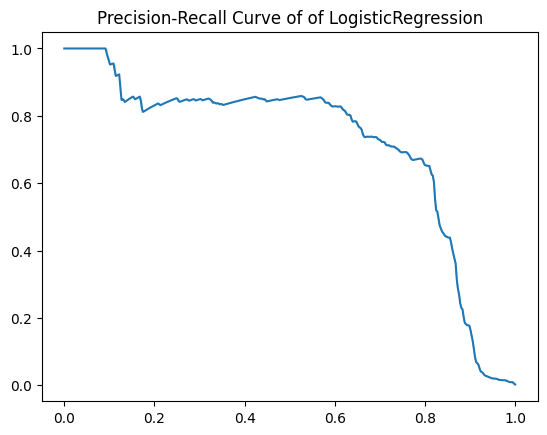

In [82]:
precision, recall, thresold = precision_recall_curve(Y_val, y_pred_proba_logreg)
sns.lineplot(x=recall, y=precision)
plt.title("Precision-Recall Curve of of LogisticRegression")

Text(0.5, 1.0, 'Precision-Recall Curve of XGBClassifier')

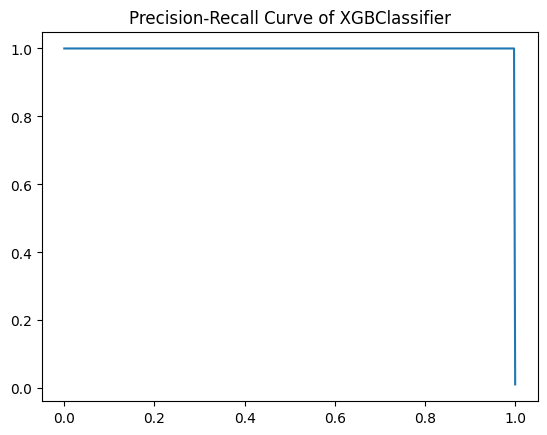

In [83]:
precision, recall, thresold = precision_recall_curve(Y_val, y_pred_proba_xgb)
sns.lineplot(x=recall, y=precision)
plt.title("Precision-Recall Curve of XGBClassifier")

In [84]:
y_pred_xgb = (y_pred_proba_xgb > 0.5).astype(int) 
print(confusion_matrix(Y_val, y_pred_xgb))

[[227451      0]
 [     6    388]]


In [85]:
y_pred_loreg = (y_pred_proba_logreg > 0.5).astype(int) 
print(confusion_matrix(Y_val, y_pred_loreg))

[[220653   6798]
 [    31    363]]


In [86]:
y_pred_rf = (y_pred_proba_rf > 0.5).astype(int) 
print(confusion_matrix(Y_val, y_pred_rf))

[[227451      0]
 [     1    393]]


## Fine-Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(rf, param_grid, cv=3, scoring="roc_auc")
grid.fit(X_train, Y_train)

print("Best Params:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)
